In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
df = pd.read_csv("mymoviedb.csv",lineterminator='\n')

In [3]:
# df["Popularity"].plot(kind = "kde")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


# Data_Wrangling 
1) data Gathering.
2) identifying problems in a data.
3) solving the problem which we have discovered in step no. 2 

In [5]:
df.duplicated().sum()

0

In [6]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [7]:
df["Genre"]

0       Action, Adventure, Science Fiction
1                 Crime, Mystery, Thriller
2                                 Thriller
3       Animation, Comedy, Family, Fantasy
4         Action, Adventure, Thriller, War
                       ...                
9822                          Drama, Crime
9823                                Horror
9824             Mystery, Thriller, Horror
9825                 Music, Drama, History
9826           War, Drama, Science Fiction
Name: Genre, Length: 9827, dtype: object

In [8]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [9]:
df["Vote_Average"].describe()

count    9827.000000
mean        6.439534
std         1.129759
min         0.000000
25%         5.900000
50%         6.500000
75%         7.100000
max        10.000000
Name: Vote_Average, dtype: float64

# Cleaning the Problems that we have identified in step 2

In [10]:
# changing data type of Release_data 


df["Release_Date"] = pd.to_datetime(df["Release_Date"])

In [11]:
# Dropping 3 columns Overview, Original_Language, Poster_Url


df.drop(columns = ["Overview", "Original_Language","Poster_Url"],axis = 1, inplace = True)




In [12]:
""" Removing the white spaces which are avaliable in Genre and we need to split the genre in a catgorical column. 
each category will have different line and it will increase the number of lines in dataset.
"""

df["New_Genre"] = df["Genre"].str.split(", ")
df = df.explode("New_Genre").reset_index(drop = True)


# We have successfully removed the white space problem. and dataset shape has increased to ==> 25793 rows


# end of Data_wrangling 

In [13]:
# Now extracting year form Realese_Date column, it will add a new column in our dataset 
df["Year"] = df["Release_Date"].dt.year

In [14]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,New_Genre,Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",Action,2021
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",Adventure,2021
2,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",Science Fiction,2021
3,2022-03-01,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",Crime,2022
4,2022-03-01,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",Mystery,2022


In [15]:
def label(val):
    if val >=0 and val <5.9:
        return "Below Average"
    elif  val >=5.9 and val < 6.5:
        return "Average"
    elif  val >=6.5 and val < 7.1:
        return "Above Average"
    elif  val >=7.1 and val <= 10:
        return "Popular"
    else :
        return val 



df["Rating"] = df["Vote_Average"].apply(label)
df["Rating"].value_counts()

Rating
Popular          7560
Above Average    6714
Average          6134
Below Average    5385
Name: count, dtype: int64

In [16]:
# casting Rating column from object to category 

df["Rating"] = df["Rating"].astype("category")

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25793 entries, 0 to 25792
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Release_Date  25793 non-null  datetime64[ns]
 1   Title         25793 non-null  object        
 2   Popularity    25793 non-null  float64       
 3   Vote_Count    25793 non-null  int64         
 4   Vote_Average  25793 non-null  float64       
 5   Genre         25793 non-null  object        
 6   New_Genre     25793 non-null  object        
 7   Year          25793 non-null  int32         
 8   Rating        25793 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(2), int32(1), int64(1), object(3)
memory usage: 1.5+ MB


# Data Visualization 

# 1) what is the most frequent genre of movies is released on NETFLIX PLATFORM?


In [18]:
data_genre = df["New_Genre"].value_counts().sort_values(ascending = False).reset_index()
data_genre


,New_Genre,count
0,Drama,3744
1,Comedy,3031
2,Action,2686
3,Thriller,2488
4,Adventure,1853
5,Romance,1476
6,Horror,1470
7,Animation,1439
8,Family,1414
9,Fantasy,1308


In [19]:
sns.set_style("darkgrid")

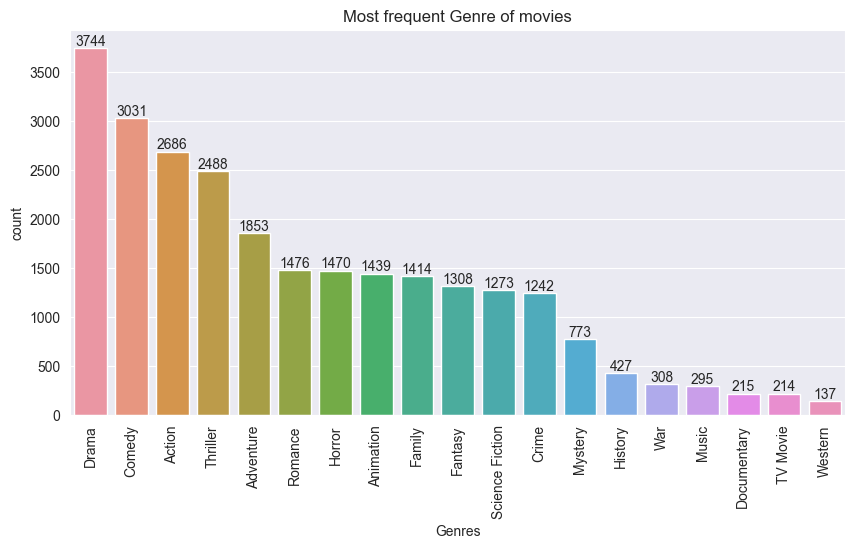

In [20]:

plt.figure(figsize = (10,5))
ax = sns.barplot(data = data_genre, x = "New_Genre", y = "count" )
ax.bar_label(ax.containers[0])
plt.xlabel("Genres")
plt.title("Most frequent Genre of movies")
plt.xticks(rotation = 90)
plt.show()

# Q. 2) which genre has the highest votes in Rating column?

In [21]:
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,New_Genre,Year,Rating
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",Action,2021,Popular
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",Adventure,2021,Popular


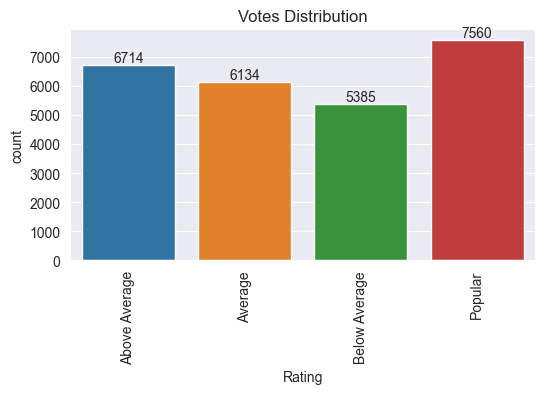

In [22]:
data_rating = df["Rating"].value_counts().sort_values(ascending = False).reset_index()
data_rating
plt.figure(figsize = (6,3))
ax = sns.barplot(data = data_rating, x = "Rating", y = "count" )
ax.bar_label(ax.containers[0])
plt.xlabel("Rating")
plt.title("Votes Distribution")
plt.xticks(rotation = 90)
plt.show()

In [23]:
q_2 = df.groupby(["Rating", "New_Genre"]).agg({"Title":"count"}).sort_values(by = "Title", ascending =False).reset_index().head(1)

# Q. 3 which movies got the highest popularity? what's it's genre

In [24]:
df[df["Popularity"] == df["Popularity"].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,New_Genre,Year,Rating
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",Action,2021,Popular
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",Adventure,2021,Popular
2,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",Science Fiction,2021,Popular


# Q. 4 which movies got the lowest popularity? what's it's genre

In [25]:
df[df["Popularity"] == df["Popularity"].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,New_Genre,Year,Rating
25787,2021-03-31,The United States vs. Billie Holiday,13.354,152,6.7,"Music, Drama, History",Music,2021,Above Average
25788,2021-03-31,The United States vs. Billie Holiday,13.354,152,6.7,"Music, Drama, History",Drama,2021,Above Average
25789,2021-03-31,The United States vs. Billie Holiday,13.354,152,6.7,"Music, Drama, History",History,2021,Above Average
25790,1984-09-23,Threads,13.354,186,7.8,"War, Drama, Science Fiction",War,1984,Popular
25791,1984-09-23,Threads,13.354,186,7.8,"War, Drama, Science Fiction",Drama,1984,Popular
25792,1984-09-23,Threads,13.354,186,7.8,"War, Drama, Science Fiction",Science Fiction,1984,Popular


# Q. 5 Which Year has the most filmed movies?

Text(0.5, 1.0, 'Most movies filled year')

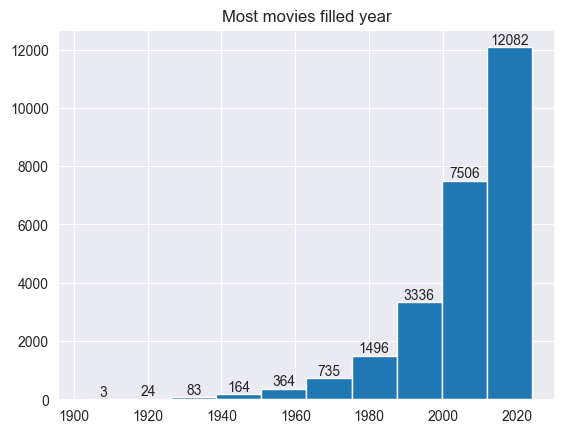

In [26]:
ax = df["Year"].hist()
ax.bar_label(ax.containers[0])
plt.title("Most movies filled year")

In [27]:
# Cross checking with value_counts.
df["Year"].value_counts()

Year
2021    1638
2018    1387
2017    1365
2019    1272
2016    1212
        ... 
2024       4
1902       3
1925       2
1929       2
1930       2
Name: count, Length: 102, dtype: int64

# Conclusion

# END OF THE PROJECT, THANK YOU